# Draft 4: CatBoost Ensemble (Manual)

In [2]:
import importlib.util
import subprocess
import sys


def run_cmd(cmd):
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)


if importlib.util.find_spec("catboost") is None:
    installed = False
    print("catboost not found. Trying install with pip...")
    try:
        run_cmd([sys.executable, "-m", "pip", "install", "catboost"])
        installed = True
    except subprocess.CalledProcessError:
        print("pip install failed. Trying ensurepip then pip...")
        try:
            run_cmd([sys.executable, "-m", "ensurepip", "--upgrade"])
            run_cmd([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
            run_cmd([sys.executable, "-m", "pip", "install", "catboost"])
            installed = True
        except subprocess.CalledProcessError:
            print("ensurepip path failed. Trying uv pip...")
            run_cmd(["uv", "pip", "install", "--python", sys.executable, "catboost"])
            installed = True

    if not installed:
        raise RuntimeError("Failed to install catboost with pip/ensurepip/uv")

if importlib.util.find_spec("catboost") is None:
    raise RuntimeError("catboost is still not available after installation attempts")

print("catboost is ready")


catboost not found. Trying install with pip...
Running: /Users/beam/Workspace/Course/my-cpe-lab/Y2/CPE232/.venv/bin/python -m pip install catboost
pip install failed. Trying ensurepip then pip...
Running: /Users/beam/Workspace/Course/my-cpe-lab/Y2/CPE232/.venv/bin/python -m ensurepip --upgrade


/Users/beam/Workspace/Course/my-cpe-lab/Y2/CPE232/.venv/bin/python: No module named pip


Looking in links: /var/folders/js/tpfy4qxs76jf4199skp9p6n40000gn/T/tmpjlilrxg4
Processing /var/folders/js/tpfy4qxs76jf4199skp9p6n40000gn/T/tmpjlilrxg4/pip-25.0.1-py3-none-any.whl
Running: /Users/beam/Workspace/Course/my-cpe-lab/Y2/CPE232/.venv/bin/python -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1
Running: /Users/beam/Workspace/Course/my-cpe-lab/Y2/CPE232/.venv/bin/python -m pip install catboost
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 5.4 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [catboost]1/2 [catboost]
catboost is ready


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


In [4]:
NOTEBOOK_DIR_NAME = "kaggle/01-fraudulent-transaction-detect"
candidate_base_dirs = [
    Path.cwd(),
    Path.cwd() / NOTEBOOK_DIR_NAME,
    Path(
        "/Users/beam/Workspace/Course/my-cpe-lab/Y2/CPE232/kaggle/01-fraudulent-transaction-detect"
    ),
]
BASE_DIR = next(
    (
        candidate
        for candidate in candidate_base_dirs
        if (candidate / "data" / "train.csv").exists()
    ),
    None,
)
if BASE_DIR is None:
    raise FileNotFoundError("Could not find Kaggle 01 data folder")

DATA_DIR = BASE_DIR / "data"
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_PATH = DATA_DIR / "sample_submission.csv"
OUTPUT_PATH = BASE_DIR / "submission_draft4_catboost.csv"

ID_COL = "id"
LABEL_COL = "is_fraud"
TIME_COL = "time_ind"
RANDOM_STATE = 42
N_SPLITS = 5
PRIMARY_VALID_SIZE = 0.20
TIME_VALID_FRACTION = 0.15
THRESHOLD_GRID = np.round(np.arange(0.005, 0.955, 0.005), 3)
NEGATIVE_CAP_OOF = 850_000
NEGATIVE_CAP_FINAL = None
PSEUDO_POS_THRESHOLD = 0.995
PSEUDO_NEG_THRESHOLD = 0.001
MAX_PSEUDO_PER_CLASS = 150_000
ENABLE_PSEUDOLABEL = True

print("Base directory:", BASE_DIR)
print("Output path:", OUTPUT_PATH)


Base directory: /Users/beam/Workspace/Course/my-cpe-lab/Y2/CPE232/kaggle/01-fraudulent-transaction-detect
Output path: /Users/beam/Workspace/Course/my-cpe-lab/Y2/CPE232/kaggle/01-fraudulent-transaction-detect/submission_draft4_catboost.csv


In [5]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

expected_train_cols = {
    "id",
    "time_ind",
    "transac_type",
    "amount",
    "src_acc",
    "src_bal",
    "src_new_bal",
    "dst_acc",
    "dst_bal",
    "dst_new_bal",
    "is_fraud",
    "is_flagged_fraud",
}
expected_test_cols = expected_train_cols - {LABEL_COL}

assert set(train_df.columns) == expected_train_cols, "Train schema mismatch"
assert set(test_df.columns) == expected_test_cols, "Test schema mismatch"
assert LABEL_COL not in test_df.columns, "Test must not include label"
assert train_df[ID_COL].is_unique, "Duplicate IDs in train"
assert test_df[ID_COL].is_unique, "Duplicate IDs in test"
assert sample_submission.columns.tolist() == [ID_COL, LABEL_COL], (
    "Unexpected sample submission schema"
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Class ratio:")
display(train_df[LABEL_COL].value_counts(normalize=True).to_frame("ratio"))


Train shape: (5408227, 12)
Test shape: (954393, 11)
Class ratio:


,ratio
is_fraud,
0,0.998709
1,0.001291


,train_missing,train_missing_pct,test_missing,test_missing_pct
amount,702632,12.991910,"123,755.000000",12.966881
transac_type,648331,11.987866,"114,313.000000",11.977561
dst_bal,270191,4.995926,"48,076.000000",5.037338
src_bal,269799,4.988677,"47,687.000000",4.996579
dst_acc,0,0.000000,0.000000,0.000000
dst_new_bal,0,0.000000,0.000000,0.000000
id,0,0.000000,0.000000,0.000000
is_flagged_fraud,0,0.000000,0.000000,0.000000
is_fraud,0,0.000000,NaN,NaN
src_acc,0,0.000000,0.000000,0.000000


is_fraud,non_fraud_rate,fraud_rate
transac_type,,
CASH_IN,1.000000,0.000000
CASH_OUT,0.998338,0.001662
DEBIT,1.000000,0.000000
MISSING,0.997747,0.002253
PAYMENT,1.000000,0.000000
TRANSFER,0.992269,0.007731


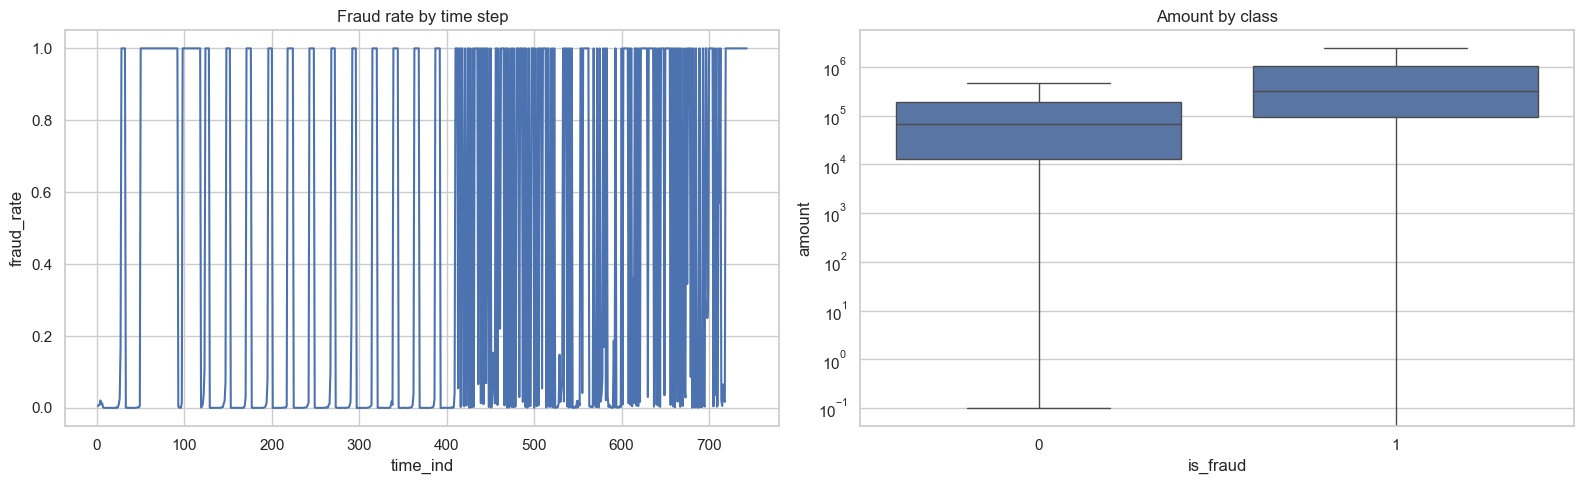

In [6]:
missing_summary = pd.DataFrame(
    {
        "train_missing": train_df.isna().sum(),
        "train_missing_pct": train_df.isna().mean() * 100,
        "test_missing": test_df.isna().sum(),
        "test_missing_pct": test_df.isna().mean() * 100,
    }
).sort_values("train_missing", ascending=False)
display(missing_summary)

fraud_by_type = pd.crosstab(
    train_df["transac_type"].fillna("MISSING"),
    train_df[LABEL_COL],
    normalize="index",
).rename(columns={0: "non_fraud_rate", 1: "fraud_rate"})
display(fraud_by_type)

fraud_by_time = (
    train_df.groupby(TIME_COL, observed=True)[LABEL_COL]
    .mean()
    .reset_index(name="fraud_rate")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=fraud_by_time, x=TIME_COL, y="fraud_rate", ax=axes[0])
axes[0].set_title("Fraud rate by time step")

tmp = train_df[["amount", LABEL_COL]].dropna()
tmp = tmp.sample(min(len(tmp), 200_000), random_state=RANDOM_STATE)
sns.boxplot(data=tmp, x=LABEL_COL, y="amount", showfliers=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Amount by class")
plt.tight_layout()
plt.show()


## Feature Engineering + Leakage-safe Mapping

We use two map groups:
- non-target maps (safe to build from training partition)
- target maps (fraud history/rate), built per fold for validation rows to avoid leakage


In [7]:
def downsample_keep_all_positive(df, negative_cap, random_state=RANDOM_STATE):
    if negative_cap is None:
        return df.copy()
    pos_df = df[df[LABEL_COL] == 1]
    neg_df = df[df[LABEL_COL] == 0]
    if len(neg_df) > negative_cap:
        neg_df = neg_df.sample(negative_cap, random_state=random_state)
    sampled = pd.concat([pos_df, neg_df], axis=0)
    return sampled.sample(frac=1, random_state=random_state).reset_index(drop=True)


def make_time_holdout(df, valid_fraction=TIME_VALID_FRACTION):
    unique_steps = np.sort(df[TIME_COL].unique())
    n_valid_steps = max(1, int(np.ceil(len(unique_steps) * valid_fraction)))
    valid_steps = unique_steps[-n_valid_steps:]
    valid_mask = df[TIME_COL].isin(valid_steps)
    train_part = df.loc[~valid_mask].copy()
    valid_part = df.loc[valid_mask].copy()
    assert train_part[LABEL_COL].nunique() == 2
    assert valid_part[LABEL_COL].nunique() == 2
    return train_part, valid_part


def build_non_target_maps(fit_df):
    src_stats = fit_df.groupby("src_acc", observed=True).agg(
        src_txn_count=(ID_COL, "size"),
        src_unique_dst=("dst_acc", "nunique"),
        src_first_step=(TIME_COL, "min"),
        src_last_step=(TIME_COL, "max"),
    )
    src_stats["src_step_span"] = (
        src_stats["src_last_step"] - src_stats["src_first_step"]
    )

    dst_stats = fit_df.groupby("dst_acc", observed=True).agg(
        dst_txn_count=(ID_COL, "size"),
        dst_unique_src=("src_acc", "nunique"),
        dst_first_step=(TIME_COL, "min"),
        dst_last_step=(TIME_COL, "max"),
    )
    dst_stats["dst_step_span"] = (
        dst_stats["dst_last_step"] - dst_stats["dst_first_step"]
    )

    numeric_cols = ["amount", "src_bal", "src_new_bal", "dst_bal", "dst_new_bal"]
    medians = {col: float(fit_df[col].median()) for col in numeric_cols}
    late_step_cutoff = int(fit_df[TIME_COL].quantile(0.85))

    return {
        "src_stats": src_stats,
        "dst_stats": dst_stats,
        "medians": medians,
        "late_step_cutoff": late_step_cutoff,
    }


def build_target_maps(fit_df, smoothing=20.0):
    global_rate = float(fit_df[LABEL_COL].mean())

    src_agg = fit_df.groupby("src_acc", observed=True)[LABEL_COL].agg(["sum", "count"])
    src_agg["src_fraud_count"] = src_agg["sum"]
    src_agg["src_fraud_rate"] = (src_agg["sum"] + smoothing * global_rate) / (
        src_agg["count"] + smoothing
    )

    dst_agg = fit_df.groupby("dst_acc", observed=True)[LABEL_COL].agg(["sum", "count"])
    dst_agg["dst_fraud_count"] = dst_agg["sum"]
    dst_agg["dst_fraud_rate"] = (dst_agg["sum"] + smoothing * global_rate) / (
        dst_agg["count"] + smoothing
    )

    return {
        "src_target": src_agg[["src_fraud_count", "src_fraud_rate"]],
        "dst_target": dst_agg[["dst_fraud_count", "dst_fraud_rate"]],
        "global_rate": global_rate,
    }


def make_features(df, non_target_maps, target_maps=None):
    med = non_target_maps["medians"]
    X = pd.DataFrame(index=df.index)

    X["transac_type"] = df["transac_type"].fillna("MISSING").astype(str)
    X["src_acc"] = df["src_acc"].astype(str)
    X["dst_acc"] = df["dst_acc"].astype(str)

    amount = df["amount"].fillna(med["amount"]).astype("float64")
    src_bal = df["src_bal"].fillna(med["src_bal"]).astype("float64")
    src_new_bal = df["src_new_bal"].fillna(med["src_new_bal"]).astype("float64")
    dst_bal = df["dst_bal"].fillna(med["dst_bal"]).astype("float64")
    dst_new_bal = df["dst_new_bal"].fillna(med["dst_new_bal"]).astype("float64")

    X["time_ind"] = df[TIME_COL].astype("float64")
    X["is_flagged_fraud"] = df["is_flagged_fraud"].astype("float64")
    X["amount"] = amount
    X["src_bal"] = src_bal
    X["src_new_bal"] = src_new_bal
    X["dst_bal"] = dst_bal
    X["dst_new_bal"] = dst_new_bal

    X["amount_missing"] = df["amount"].isna().astype("float64")
    X["src_bal_missing"] = df["src_bal"].isna().astype("float64")
    X["dst_bal_missing"] = df["dst_bal"].isna().astype("float64")
    X["transac_type_missing"] = df["transac_type"].isna().astype("float64")

    X["log_amount"] = np.log1p(amount)
    X["src_delta"] = src_bal - src_new_bal
    X["dst_delta"] = dst_new_bal - dst_bal
    X["src_balance_error"] = np.abs(src_bal - src_new_bal - amount)
    X["dst_balance_error"] = np.abs(dst_new_bal - dst_bal - amount)
    X["amount_to_src_ratio"] = amount / (np.abs(src_bal) + 1.0)
    X["amount_to_dst_ratio"] = amount / (np.abs(dst_bal) + 1.0)

    X["src_zero_before"] = (src_bal == 0).astype("float64")
    X["src_zero_after"] = (src_new_bal == 0).astype("float64")
    X["dst_zero_before"] = (dst_bal == 0).astype("float64")
    X["dst_zero_after"] = (dst_new_bal == 0).astype("float64")
    X["source_emptied_flag"] = ((src_bal > 0) & (src_new_bal == 0)).astype("float64")
    X["destination_unchanged_flag"] = (dst_bal == dst_new_bal).astype("float64")
    X["same_account_flag"] = (df["src_acc"] == df["dst_acc"]).astype("float64")

    hour = df[TIME_COL] % 24
    X["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    X["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    X["late_step_flag"] = (df[TIME_COL] >= non_target_maps["late_step_cutoff"]).astype(
        "float64"
    )

    X["is_transfer"] = (X["transac_type"] == "TRANSFER").astype("float64")
    X["is_cash_out"] = (X["transac_type"] == "CASH_OUT").astype("float64")
    X["amount_x_transfer"] = X["amount"] * X["is_transfer"]
    X["amount_x_cash_out"] = X["amount"] * X["is_cash_out"]
    X["source_emptied_x_transfer"] = X["source_emptied_flag"] * X["is_transfer"]
    X["source_emptied_x_cash_out"] = X["source_emptied_flag"] * X["is_cash_out"]

    X["log_amount_bin"] = pd.cut(
        X["log_amount"], bins=16, labels=False, include_lowest=True
    ).astype(str)
    X["time_bin"] = pd.cut(
        X["time_ind"], bins=20, labels=False, include_lowest=True
    ).astype(str)

    src_stats = non_target_maps["src_stats"]
    dst_stats = non_target_maps["dst_stats"]
    X = X.join(src_stats, on="src_acc")
    X = X.join(dst_stats, on="dst_acc")

    for col in [
        "src_txn_count",
        "src_unique_dst",
        "src_first_step",
        "src_last_step",
        "src_step_span",
        "dst_txn_count",
        "dst_unique_src",
        "dst_first_step",
        "dst_last_step",
        "dst_step_span",
    ]:
        X[col] = X[col].fillna(0.0).astype("float64")

    if target_maps is not None:
        src_target = target_maps["src_target"]
        dst_target = target_maps["dst_target"]
        g = target_maps["global_rate"]
        X = X.join(src_target, on="src_acc")
        X = X.join(dst_target, on="dst_acc")
        X["src_fraud_count"] = X["src_fraud_count"].fillna(0.0).astype("float64")
        X["dst_fraud_count"] = X["dst_fraud_count"].fillna(0.0).astype("float64")
        X["src_fraud_rate"] = X["src_fraud_rate"].fillna(g).astype("float64")
        X["dst_fraud_rate"] = X["dst_fraud_rate"].fillna(g).astype("float64")
    else:
        X["src_fraud_count"] = 0.0
        X["dst_fraud_count"] = 0.0
        X["src_fraud_rate"] = 0.0
        X["dst_fraud_rate"] = 0.0

    assert not X.isna().any().any(), "NaN found after feature engineering"
    return X


## OOF Training + Blend + Threshold Search


In [8]:
catboost_a_params = {
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "depth": 7,
    "learning_rate": 0.05,
    "l2_leaf_reg": 5.0,
    "iterations": 1400,
    "random_seed": RANDOM_STATE,
    "verbose": False,
    "allow_writing_files": False,
}

catboost_b_params = {
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "depth": 9,
    "learning_rate": 0.035,
    "l2_leaf_reg": 9.0,
    "iterations": 1800,
    "random_seed": RANDOM_STATE + 1,
    "verbose": False,
    "allow_writing_files": False,
}

hgb_params = {
    "learning_rate": 0.05,
    "max_depth": 8,
    "max_iter": 350,
    "min_samples_leaf": 80,
    "random_state": RANDOM_STATE,
}

blend_weight_grid = [
    (0.45, 0.45, 0.10),
    (0.50, 0.40, 0.10),
    (0.40, 0.50, 0.10),
    (0.55, 0.35, 0.10),
    (0.35, 0.55, 0.10),
    (0.45, 0.40, 0.15),
    (0.40, 0.45, 0.15),
    (0.50, 0.35, 0.15),
    (0.35, 0.50, 0.15),
    (0.55, 0.45, 0.00),
    (0.45, 0.55, 0.00),
    (0.60, 0.40, 0.00),
    (0.40, 0.60, 0.00),
]


def metric_at_threshold(y_true, prob, threshold):
    pred = (prob >= threshold).astype(int)
    return {
        "macro_f1": f1_score(y_true, pred, average="macro", zero_division=0),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "positive_rate": float(pred.mean()),
    }


def threshold_search(y_true, prob, thresholds=THRESHOLD_GRID):
    rows = []
    for t in thresholds:
        m = metric_at_threshold(y_true, prob, t)
        rows.append({"threshold": float(t), **m})
    df = pd.DataFrame(rows).sort_values(
        ["macro_f1", "recall"], ascending=[False, False]
    )
    return df, df.iloc[0].to_dict()


def cat_features_for_frame(X):
    return [
        "transac_type",
        "src_acc",
        "dst_acc",
        "log_amount_bin",
        "time_bin",
    ]


def compute_class_weights(y, boost_positive=1.0):
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    ratio = (neg / max(pos, 1)) * boost_positive
    ratio = float(np.clip(ratio, 10.0, 600.0))
    return [1.0, ratio]


In [9]:
train_main_df = downsample_keep_all_positive(train_df, negative_cap=NEGATIVE_CAP_OOF)
test_for_pred_df = test_df.copy()
y_main = train_main_df[LABEL_COL].astype(int).reset_index(drop=True)
train_main_df = train_main_df.reset_index(drop=True)

print("OOF training rows:", len(train_main_df))
print("OOF fraud ratio:", y_main.mean())

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof_a = np.zeros(len(train_main_df), dtype=float)
oof_b = np.zeros(len(train_main_df), dtype=float)
oof_h = np.zeros(len(train_main_df), dtype=float)
test_pred_a_folds = []
test_pred_b_folds = []
test_pred_h_folds = []

for fold, (fit_idx, valid_idx) in enumerate(skf.split(train_main_df, y_main), start=1):
    fold_fit_df = train_main_df.iloc[fit_idx].copy()
    fold_valid_df = train_main_df.iloc[valid_idx].copy()
    y_fit = fold_fit_df[LABEL_COL].astype(int)
    y_valid = fold_valid_df[LABEL_COL].astype(int)

    non_target_maps = build_non_target_maps(fold_fit_df)
    target_maps = build_target_maps(fold_fit_df)

    X_fit = make_features(fold_fit_df, non_target_maps, target_maps=target_maps)
    X_valid = make_features(fold_valid_df, non_target_maps, target_maps=target_maps)
    X_test_fold = make_features(
        test_for_pred_df, non_target_maps, target_maps=target_maps
    )

    cat_cols = cat_features_for_frame(X_fit)
    cat_idx = [X_fit.columns.get_loc(c) for c in cat_cols]

    w_a = compute_class_weights(y_fit, boost_positive=1.15)
    w_b = compute_class_weights(y_fit, boost_positive=0.90)

    model_a = CatBoostClassifier(**catboost_a_params, class_weights=w_a)
    model_b = CatBoostClassifier(**catboost_b_params, class_weights=w_b)

    model_a.fit(X_fit, y_fit, cat_features=cat_idx)
    model_b.fit(X_fit, y_fit, cat_features=cat_idx)

    hgb_fit_X = X_fit.drop(columns=cat_cols)
    hgb_valid_X = X_valid.drop(columns=cat_cols)
    hgb_test_X = X_test_fold.drop(columns=cat_cols)
    model_h = HistGradientBoostingClassifier(**hgb_params)
    model_h.fit(hgb_fit_X, y_fit)

    oof_a[valid_idx] = model_a.predict_proba(X_valid)[:, 1]
    oof_b[valid_idx] = model_b.predict_proba(X_valid)[:, 1]
    oof_h[valid_idx] = model_h.predict_proba(hgb_valid_X)[:, 1]

    test_pred_a_folds.append(model_a.predict_proba(X_test_fold)[:, 1])
    test_pred_b_folds.append(model_b.predict_proba(X_test_fold)[:, 1])
    test_pred_h_folds.append(model_h.predict_proba(hgb_test_X)[:, 1])

    fold_blend_default = (
        0.45 * oof_a[valid_idx] + 0.45 * oof_b[valid_idx] + 0.10 * oof_h[valid_idx]
    )
    fold_metric = f1_score(
        y_valid,
        (fold_blend_default >= 0.5).astype(int),
        average="macro",
        zero_division=0,
    )
    print(f"Fold {fold}/{N_SPLITS} done | default-0.5 macro F1={fold_metric:.6f}")

test_pred_a = np.mean(np.vstack(test_pred_a_folds), axis=0)
test_pred_b = np.mean(np.vstack(test_pred_b_folds), axis=0)
test_pred_h = np.mean(np.vstack(test_pred_h_folds), axis=0)


OOF training rows: 856981
OOF fraud ratio: 0.008146038243554992


KeyboardInterrupt: 

In [ ]:
blend_rows = []
for wa, wb, wh in blend_weight_grid:
    if not np.isclose(wa + wb + wh, 1.0):
        continue
    oof_blend = wa * oof_a + wb * oof_b + wh * oof_h
    _, best = threshold_search(y_main.values, oof_blend)
    blend_rows.append(
        {
            "wa": wa,
            "wb": wb,
            "wh": wh,
            "best_threshold": best["threshold"],
            "macro_f1": best["macro_f1"],
            "precision": best["precision"],
            "recall": best["recall"],
            "positive_rate": best["positive_rate"],
        }
    )

blend_df = pd.DataFrame(blend_rows).sort_values(
    ["macro_f1", "recall"], ascending=[False, False]
)
display(blend_df.head(15))

best_blend = blend_df.iloc[0].to_dict()
BEST_WA = float(best_blend["wa"])
BEST_WB = float(best_blend["wb"])
BEST_WH = float(best_blend["wh"])
BEST_THRESHOLD = float(best_blend["best_threshold"])

print("Best blend weights:", BEST_WA, BEST_WB, BEST_WH)
print("Best OOF threshold:", BEST_THRESHOLD)
print("Best OOF macro F1:", float(best_blend["macro_f1"]))

oof_blend = BEST_WA * oof_a + BEST_WB * oof_b + BEST_WH * oof_h
oof_pred = (oof_blend >= BEST_THRESHOLD).astype(int)
oof_cm = confusion_matrix(y_main.values, oof_pred)
display(
    pd.DataFrame(oof_cm, index=["actual_0", "actual_1"], columns=["pred_0", "pred_1"])
)


## Stratified + Time-aware Holdout Validation


In [ ]:
def train_and_predict_triplet(
    train_part, valid_part, test_part, random_state=RANDOM_STATE
):
    y_train = train_part[LABEL_COL].astype(int)
    y_valid = valid_part[LABEL_COL].astype(int)

    nt_maps = build_non_target_maps(train_part)
    tg_maps = build_target_maps(train_part)

    X_train = make_features(train_part, nt_maps, target_maps=tg_maps)
    X_valid = make_features(valid_part, nt_maps, target_maps=tg_maps)
    X_test = make_features(test_part, nt_maps, target_maps=tg_maps)

    cat_cols = cat_features_for_frame(X_train)
    cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

    w_a = compute_class_weights(y_train, boost_positive=1.15)
    w_b = compute_class_weights(y_train, boost_positive=0.90)

    model_a = CatBoostClassifier(**catboost_a_params, class_weights=w_a)
    model_b = CatBoostClassifier(**catboost_b_params, class_weights=w_b)
    model_a.fit(X_train, y_train, cat_features=cat_idx)
    model_b.fit(X_train, y_train, cat_features=cat_idx)

    hgb = HistGradientBoostingClassifier(**hgb_params)
    hgb.fit(X_train.drop(columns=cat_cols), y_train)

    p_valid = (
        BEST_WA * model_a.predict_proba(X_valid)[:, 1]
        + BEST_WB * model_b.predict_proba(X_valid)[:, 1]
        + BEST_WH * hgb.predict_proba(X_valid.drop(columns=cat_cols))[:, 1]
    )
    p_test = (
        BEST_WA * model_a.predict_proba(X_test)[:, 1]
        + BEST_WB * model_b.predict_proba(X_test)[:, 1]
        + BEST_WH * hgb.predict_proba(X_test.drop(columns=cat_cols))[:, 1]
    )
    return y_valid.values, p_valid, p_test


strat_train, strat_valid = train_test_split(
    train_df,
    test_size=PRIMARY_VALID_SIZE,
    random_state=RANDOM_STATE,
    stratify=train_df[LABEL_COL],
)
time_train, time_valid = make_time_holdout(train_df, valid_fraction=TIME_VALID_FRACTION)

y_sv, p_sv, _ = train_and_predict_triplet(strat_train, strat_valid, test_df)
y_tv, p_tv, _ = train_and_predict_triplet(time_train, time_valid, test_df)

strat_metrics = metric_at_threshold(y_sv, p_sv, BEST_THRESHOLD)
time_metrics = metric_at_threshold(y_tv, p_tv, BEST_THRESHOLD)

print("Stratified holdout metrics @ OOF threshold")
print(pd.Series(strat_metrics))
print("\nTime-aware holdout metrics @ OOF threshold")
print(pd.Series(time_metrics))

display(
    pd.DataFrame(
        confusion_matrix(y_sv, (p_sv >= BEST_THRESHOLD).astype(int)),
        index=["actual_0", "actual_1"],
        columns=["pred_0", "pred_1"],
    )
)
display(
    pd.DataFrame(
        confusion_matrix(y_tv, (p_tv >= BEST_THRESHOLD).astype(int)),
        index=["actual_0", "actual_1"],
        columns=["pred_0", "pred_1"],
    )
)


## Final Full-data Training + Optional Pseudo-label Round


In [ ]:
full_train_for_fit = downsample_keep_all_positive(
    train_df, negative_cap=NEGATIVE_CAP_FINAL
)
y_full = full_train_for_fit[LABEL_COL].astype(int)

full_nt = build_non_target_maps(full_train_for_fit)
full_tg = build_target_maps(full_train_for_fit)
X_full = make_features(full_train_for_fit, full_nt, target_maps=full_tg)
X_test_full = make_features(test_df, full_nt, target_maps=full_tg)

cat_cols = cat_features_for_frame(X_full)
cat_idx = [X_full.columns.get_loc(c) for c in cat_cols]

final_model_a = CatBoostClassifier(
    **catboost_a_params,
    class_weights=compute_class_weights(y_full, boost_positive=1.15),
)
final_model_b = CatBoostClassifier(
    **catboost_b_params,
    class_weights=compute_class_weights(y_full, boost_positive=0.90),
)
final_model_h = HistGradientBoostingClassifier(**hgb_params)

final_model_a.fit(X_full, y_full, cat_features=cat_idx)
final_model_b.fit(X_full, y_full, cat_features=cat_idx)
final_model_h.fit(X_full.drop(columns=cat_cols), y_full)

test_prob_base = (
    BEST_WA * final_model_a.predict_proba(X_test_full)[:, 1]
    + BEST_WB * final_model_b.predict_proba(X_test_full)[:, 1]
    + BEST_WH * final_model_h.predict_proba(X_test_full.drop(columns=cat_cols))[:, 1]
)

test_prob_final = test_prob_base.copy()
pseudo_used = False

if ENABLE_PSEUDOLABEL:
    pseudo_pos_idx = np.where(test_prob_base >= PSEUDO_POS_THRESHOLD)[0]
    pseudo_neg_idx = np.where(test_prob_base <= PSEUDO_NEG_THRESHOLD)[0]

    if len(pseudo_pos_idx) > MAX_PSEUDO_PER_CLASS:
        order = np.argsort(test_prob_base[pseudo_pos_idx])[::-1]
        pseudo_pos_idx = pseudo_pos_idx[order[:MAX_PSEUDO_PER_CLASS]]
    if len(pseudo_neg_idx) > MAX_PSEUDO_PER_CLASS:
        order = np.argsort(test_prob_base[pseudo_neg_idx])
        pseudo_neg_idx = pseudo_neg_idx[order[:MAX_PSEUDO_PER_CLASS]]

    pseudo_idx = np.concatenate([pseudo_pos_idx, pseudo_neg_idx])
    pseudo_labels = np.concatenate(
        [
            np.ones(len(pseudo_pos_idx), dtype=int),
            np.zeros(len(pseudo_neg_idx), dtype=int),
        ]
    )

    print("Pseudo candidates (pos, neg):", len(pseudo_pos_idx), len(pseudo_neg_idx))

    if len(pseudo_idx) > 0:
        pseudo_df = test_df.iloc[pseudo_idx].copy()
        pseudo_df[LABEL_COL] = pseudo_labels
        aug_df = pd.concat([full_train_for_fit, pseudo_df], axis=0).reset_index(
            drop=True
        )

        aug_nt = build_non_target_maps(aug_df)
        aug_tg = build_target_maps(aug_df)
        X_aug = make_features(aug_df, aug_nt, target_maps=aug_tg)
        y_aug = aug_df[LABEL_COL].astype(int)
        X_test_aug = make_features(test_df, aug_nt, target_maps=aug_tg)
        aug_cat_idx = [X_aug.columns.get_loc(c) for c in cat_cols]

        model_a_aug = CatBoostClassifier(
            **catboost_a_params,
            class_weights=compute_class_weights(y_aug, boost_positive=1.15),
        )
        model_b_aug = CatBoostClassifier(
            **catboost_b_params,
            class_weights=compute_class_weights(y_aug, boost_positive=0.90),
        )
        model_h_aug = HistGradientBoostingClassifier(**hgb_params)

        model_a_aug.fit(X_aug, y_aug, cat_features=aug_cat_idx)
        model_b_aug.fit(X_aug, y_aug, cat_features=aug_cat_idx)
        model_h_aug.fit(X_aug.drop(columns=cat_cols), y_aug)

        p_test_aug = (
            BEST_WA * model_a_aug.predict_proba(X_test_aug)[:, 1]
            + BEST_WB * model_b_aug.predict_proba(X_test_aug)[:, 1]
            + BEST_WH
            * model_h_aug.predict_proba(X_test_aug.drop(columns=cat_cols))[:, 1]
        )

        def eval_split_with_pseudo(train_part, valid_part, pseudo_part):
            eval_fit_df = pd.concat(
                [train_part.copy(), pseudo_part.copy()], axis=0
            ).reset_index(drop=True)
            y_eval_train = eval_fit_df[LABEL_COL].astype(int)
            y_eval_valid = valid_part[LABEL_COL].astype(int).values

            eval_nt = build_non_target_maps(eval_fit_df)
            eval_tg = build_target_maps(eval_fit_df)
            X_eval_train = make_features(eval_fit_df, eval_nt, target_maps=eval_tg)
            X_eval_valid = make_features(valid_part, eval_nt, target_maps=eval_tg)
            eval_cat_idx = [X_eval_train.columns.get_loc(c) for c in cat_cols]

            eval_a = CatBoostClassifier(
                **catboost_a_params,
                class_weights=compute_class_weights(y_eval_train, boost_positive=1.15),
            )
            eval_b = CatBoostClassifier(
                **catboost_b_params,
                class_weights=compute_class_weights(y_eval_train, boost_positive=0.90),
            )
            eval_h = HistGradientBoostingClassifier(**hgb_params)

            eval_a.fit(X_eval_train, y_eval_train, cat_features=eval_cat_idx)
            eval_b.fit(X_eval_train, y_eval_train, cat_features=eval_cat_idx)
            eval_h.fit(X_eval_train.drop(columns=cat_cols), y_eval_train)

            p_eval_valid = (
                BEST_WA * eval_a.predict_proba(X_eval_valid)[:, 1]
                + BEST_WB * eval_b.predict_proba(X_eval_valid)[:, 1]
                + BEST_WH
                * eval_h.predict_proba(X_eval_valid.drop(columns=cat_cols))[:, 1]
            )
            return metric_at_threshold(y_eval_valid, p_eval_valid, BEST_THRESHOLD)[
                "macro_f1"
            ]

        base_strat_f1 = strat_metrics["macro_f1"]
        base_time_f1 = time_metrics["macro_f1"]
        aug_strat_f1 = eval_split_with_pseudo(strat_train, strat_valid, pseudo_df)
        aug_time_f1 = eval_split_with_pseudo(time_train, time_valid, pseudo_df)

        print("Pseudo check strat f1 (base -> aug):", base_strat_f1, "->", aug_strat_f1)
        print("Pseudo check time f1 (base -> aug):", base_time_f1, "->", aug_time_f1)

        if (aug_strat_f1 >= base_strat_f1) and (aug_time_f1 >= base_time_f1):
            test_prob_final = p_test_aug
            pseudo_used = True

print("Pseudo-label used:", pseudo_used)


In [ ]:
final_pred = (test_prob_final >= BEST_THRESHOLD).astype(int)
submission = pd.DataFrame({ID_COL: test_df[ID_COL], LABEL_COL: final_pred})

assert len(submission) == len(test_df), "Submission length mismatch"
assert submission.columns.tolist() == [ID_COL, LABEL_COL], "Submission schema mismatch"
assert set(submission[LABEL_COL].unique()).issubset({0, 1}), (
    "Submission labels must be binary"
)

submission.to_csv(OUTPUT_PATH, index=False)
print("Saved:", OUTPUT_PATH)
display(submission.head())

pred_dist = submission[LABEL_COL].value_counts().rename("rows").to_frame()
pred_dist["ratio"] = submission[LABEL_COL].value_counts(normalize=True)
display(pred_dist)


In [ ]:
summary = pd.DataFrame(
    [
        {
            "oof_macro_f1": float(best_blend["macro_f1"]),
            "oof_precision": float(best_blend["precision"]),
            "oof_recall": float(best_blend["recall"]),
            "oof_positive_rate": float(best_blend["positive_rate"]),
            "best_threshold": BEST_THRESHOLD,
            "weight_catboost_a": BEST_WA,
            "weight_catboost_b": BEST_WB,
            "weight_hgb": BEST_WH,
            "strat_macro_f1": float(strat_metrics["macro_f1"]),
            "time_macro_f1": float(time_metrics["macro_f1"]),
            "pseudo_used": bool(pseudo_used),
            "predicted_fraud_rows": int(submission[LABEL_COL].sum()),
            "predicted_fraud_rate": float(submission[LABEL_COL].mean()),
        }
    ]
)
display(summary)

print("CatBoost-A params:")
print(catboost_a_params)
print("\nCatBoost-B params:")
print(catboost_b_params)
print("\nHGB params:")
print(hgb_params)


## Notes

- This notebook is manual and local-only.
- It uses OOF blend tuning and threshold search for macro F1.
- It keeps pseudo-label only when holdout checks do not degrade.
- Upload `submission_draft4_catboost.csv` manually.
